# Distribution Feeder Synthesis from pypowsybl-Supported Formats

This notebook demonstrates how to use **pypowsybl** as the entry point for
**distribution** grid synthesis using the Schweitzer et al. (2017) algorithm.
We load a reference distribution network via pypowsybl (from CGMES file and
from pandapower conversion), then run the full feeder synthesis pipeline.

**Sections:**
1. Loading reference distribution grids via pypowsybl
2. Converting to Schweitzer-format feeders
3. Fitting synthesis parameters from reference feeders
4. Generating synthetic feeders
5. Comparison & validation
6. Visualization
7. Power-flow validation

In [1]:
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import pypowsybl as ppl
import pandapower as pp
import pandapower.networks as pn

## 1. Loading Reference Distribution Grids via pypowsybl

pypowsybl does not ship built-in distribution test networks, so we create
one from pandapower's **CIGRE Low-Voltage** benchmark, convert it to
pypowsybl format, and then save/reload via **CGMES** to demonstrate the
full file-based import path.

In practice you would load your own distribution network from any
pypowsybl-supported format:
CGMES, XIIDM, MATPOWER, IEEE-CDF, PSS/E, UCTE, BIIDM, JIIDM, POWER-FACTORY.

In [2]:
from powergrid_synth import pandapower_to_pypowsybl

# Load CIGRE LV from pandapower and convert to pypowsybl
net_pp = pn.create_cigre_network_lv()
print(f"pandapower CIGRE LV: {len(net_pp.bus)} buses, {len(net_pp.line)} lines, "
      f"{len(net_pp.trafo)} trafos")
print(f"  Loads:      {len(net_pp.load)}")
print(f"  Generators: {len(net_pp.sgen)}")

# Convert to pypowsybl Network
net_ppl = pandapower_to_pypowsybl(net_pp)
print(f"\npypowsybl network:")
print(f"  Buses:  {len(net_ppl.get_buses())}")
print(f"  Lines:  {len(net_ppl.get_lines())}")
print(f"  Loads:  {len(net_ppl.get_loads())}")

pandapower CIGRE LV: 44 buses, 37 lines, 3 trafos
  Loads:      15
  Generators: 0

pypowsybl network:
  Buses:  44
  Lines:  37
  Loads:  15


### 1.1. CGMES Round-Trip

We save the distribution grid to **CGMES** format (the Common Grid Model
Exchange Standard), then reload it via pypowsybl to demonstrate the
file-based import path.

In [3]:
# Save to CGMES
cgmes_dir = os.path.join("output", "cigre_lv_cgmes")
os.makedirs(cgmes_dir, exist_ok=True)
net_ppl.save(cgmes_dir, format="CGMES")

cgmes_files = sorted(f for f in os.listdir(cgmes_dir) if f.endswith(".xml"))
print(f"CGMES files saved to {cgmes_dir}/")
for f in cgmes_files:
    fpath = os.path.join(cgmes_dir, f)
    print(f"  {f}  ({os.path.getsize(fpath):,} bytes)")

# Reload from CGMES
net_from_cgmes = ppl.network.load(cgmes_dir)
print(f"\nReloaded from CGMES: {len(net_from_cgmes.get_buses())} buses, "
      f"{len(net_from_cgmes.get_lines())} lines")
print("CGMES round-trip OK ✓")

CGMES files saved to output/cigre_lv_cgmes/
  cigre_lv_cgmes_EQ.xml  (90,634 bytes)
  cigre_lv_cgmes_SSH.xml  (18,609 bytes)
  cigre_lv_cgmes_SV.xml  (37,051 bytes)
  cigre_lv_cgmes_TP.xml  (26,434 bytes)

Reloaded from CGMES: 44 buses, 37 lines
CGMES round-trip OK ✓


## 2. Converting to Schweitzer-Format Feeders

`pypowsybl_to_feeders()` extracts buses, lines, transformers, loads, and
generators from a pypowsybl Network and builds Schweitzer-format feeder
graphs with hop distances, node types, and power attributes.

In [4]:
from powergrid_synth.distribution import (
    pypowsybl_to_feeders,
    feeder_summary,
    DistributionSynthParams,
    SchweetzerFeederGenerator,
    fit_params_from_feeders,
    compute_emergent_properties,
    compare_feeders,
)
from powergrid_synth import GridVisualizer
from powergrid_synth.core.grid_graph import DistributionGrid

# Convert pypowsybl network to Schweitzer-format feeders
ref_feeders_raw = pypowsybl_to_feeders(net_from_cgmes)
ref_feeders = [DistributionGrid.from_nx(f) for f in ref_feeders_raw]

print(f"Extracted {len(ref_feeders)} feeder(s) from pypowsybl network\n")
for i, s in enumerate(feeder_summary(ref_feeders)):
    print(f"Feeder {i}: {s['n_nodes']} nodes, {s['n_edges']} edges, "
          f"max_hop={s['max_hop']}, is_tree={s['is_tree']}")
    print(f"  Load: {s['total_load_mw']:.3f} MW, Gen: {s['total_gen_mw']:.3f} MW")
    print(f"  Node types: {s['node_types']}")

Extracted 3 feeder(s) from pypowsybl network

Feeder 0: 19 nodes, 18 edges, max_hop=8, is_tree=True
  Load: 0.384 MW, Gen: 0.000 MW
  Node types: {'load': 6, 'intermediate': 13}
Feeder 1: 3 nodes, 2 edges, max_hop=1, is_tree=True
  Load: 0.085 MW, Gen: 0.000 MW
  Node types: {'intermediate': 2, 'load': 1}
Feeder 2: 21 nodes, 20 edges, max_hop=8, is_tree=True
  Load: 0.218 MW, Gen: 0.000 MW
  Node types: {'intermediate': 13, 'load': 8}


## 3. Fitting Synthesis Parameters from Reference Feeders

The `fit_params_from_feeders()` function extracts statistical distributions
(Negative Binomial for hop distances, Mixture Gamma for degrees, etc.)
from the reference feeders.

In [5]:
# Fit Schweitzer parameters from reference feeders
fitted_params = fit_params_from_feeders(ref_feeders)

print("Fitted parameters:")
print(f"  Negative Binomial (hop): r={fitted_params.hop_dist.r:.2f}, p={fitted_params.hop_dist.p:.2f}")
print(f"  Degree clip: a={fitted_params.degree_clip.a:.2f}, b={fitted_params.degree_clip.b:.2f}")
print(f"  Length clip: a={fitted_params.length_clip.a:.4f}, b={fitted_params.length_clip.b:.4f}")

Fitted parameters:
  Negative Binomial (hop): r=4.81, p=0.67
  Degree clip: a=3.22, b=-0.27
  Length clip: a=0.1000, b=-0.0000


/Users/maosheng/kDrive/a_postdoc/CLC_synthesizer/powergrid/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:3748: RuntimeWarning: divide by zero encountered in scalar divide
  aest = (3-s + np.sqrt((s-3)**2 + 24*s)) / (12*s)
/Users/maosheng/kDrive/a_postdoc/CLC_synthesizer/powergrid/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:3751: RuntimeWarning: invalid value encountered in scalar subtract
  a = optimize.brentq(lambda a: np.log(a) - sc.digamma(a) - s,


## 4. Generating Synthetic Feeders

Using the fitted parameters, generate a synthetic feeder matching the
reference feeder's size (number of nodes) and total load.

In [6]:
ref = ref_feeders[0]
n_target = ref.number_of_nodes()
total_load = sum(ref.nodes[n]["P_mw"] for n in ref.nodes if ref.nodes[n].get("P_mw", 0) > 0)
total_gen = sum(-ref.nodes[n]["P_mw"] for n in ref.nodes if ref.nodes[n].get("P_mw", 0) < 0)

print(f"Reference feeder: {n_target} nodes, load={total_load:.3f} MW, gen={total_gen:.3f} MW")

# Generate synthetic feeder
gen_dist = SchweetzerFeederGenerator(params=fitted_params, seed=42)
syn_feeder = gen_dist.generate_feeder(
    n_nodes=n_target,
    total_load_mw=total_load if total_load > 0 else 1.0,
    total_gen_mw=total_gen if total_gen > 0 else 0.0,
)
syn_feeder = DistributionGrid.from_nx(syn_feeder)

print(f"Synthetic feeder: {syn_feeder.number_of_nodes()} nodes, "
      f"{syn_feeder.number_of_edges()} edges, "
      f"max_hop={max(syn_feeder.nodes[n]['h'] for n in syn_feeder.nodes)}, "
      f"is_tree={nx.is_tree(syn_feeder)}")

Reference feeder: 19 nodes, load=0.384 MW, gen=0.000 MW
Synthetic feeder: 19 nodes, 18 edges, max_hop=8, is_tree=True


## 5. Comparison & Validation

Compare the emergent properties of reference and synthetic feeders,
then compute KL-divergence scores for key distributions.

In [7]:
props_ref = compute_emergent_properties(ref)
props_syn = compute_emergent_properties(syn_feeder)

print(f"{'Property':<25} {'Reference':>12} {'Synthetic':>12}")
print("-" * 52)
for key in props_ref:
    rv = props_ref[key]
    sv = props_syn[key]
    if isinstance(rv, float):
        print(f"{key:<25} {rv:>12.4f} {sv:>12.4f}")
    else:
        print(f"{key:<25} {str(rv):>12} {str(sv):>12}")

Property                     Reference    Synthetic
----------------------------------------------------
n_nodes                             19           19
n_edges                             18           18
max_hop                              8            8
mean_degree                     1.8947       1.8947
total_load_mw                   0.3838       0.4445
total_gen_mw                         0            0
frac_intermediate               0.6842       0.6842
frac_injection                  0.0000       0.0000
mean_length_km                  0.0950       0.1000
max_length_km                   0.1000       0.1000
total_length_km                 1.7100       1.8000


In [8]:
# KL-divergence between reference and synthetic feeder distributions
kl_scores = compare_feeders(ref, syn_feeder)
print("KL-divergence scores:")
for key, val in kl_scores.items():
    print(f"  {key}: {val:.4f}")

KL-divergence scores:
  hop_distance_kl: 0.1707
  degree_kl: 0.2568
  cable_length_kl: 1.3205


## 6. Visualization

Side-by-side comparison of reference and synthetic feeder topologies.

Calculating layout 'hierarchical_tree'...


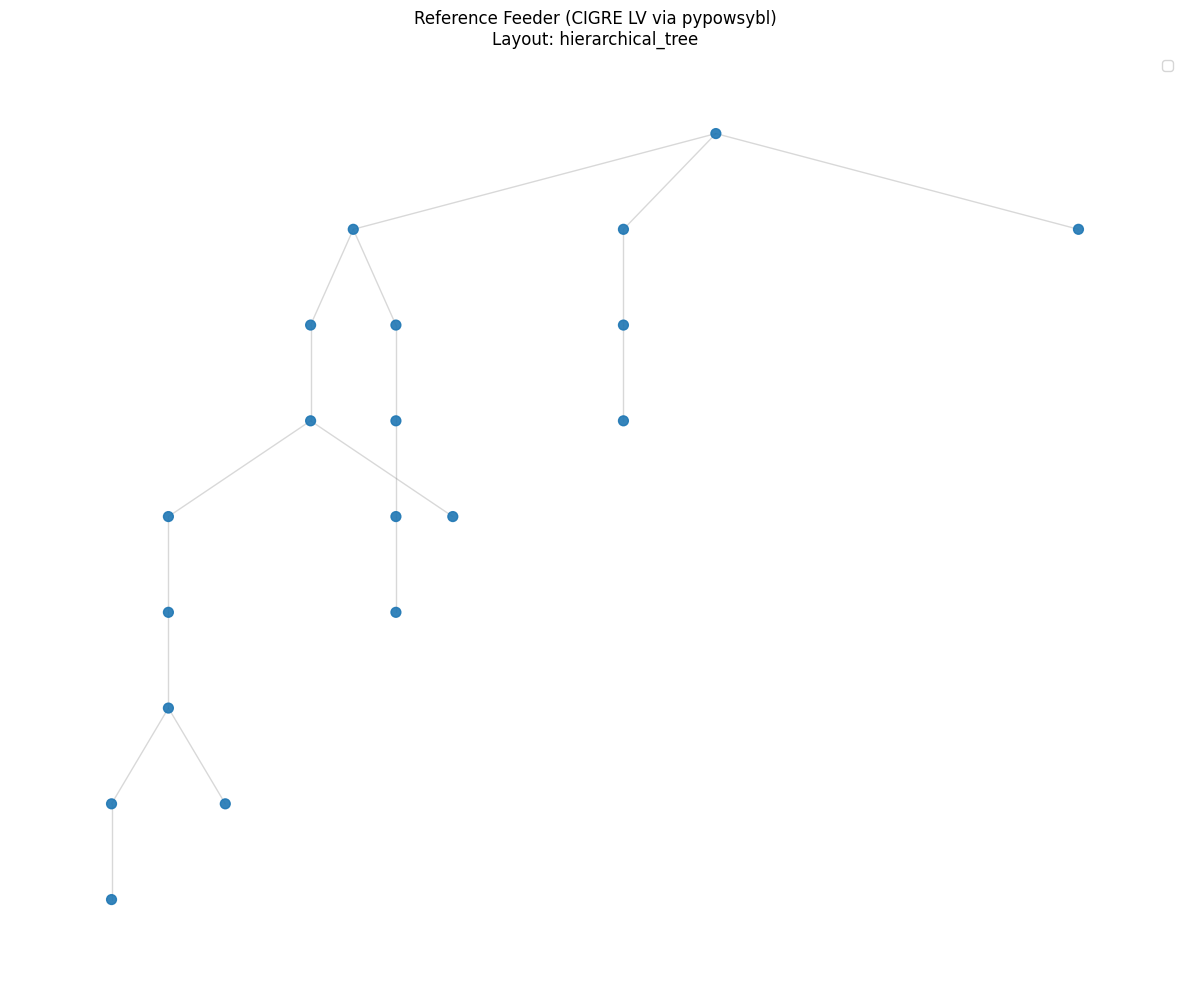

Calculating layout 'hierarchical_tree'...


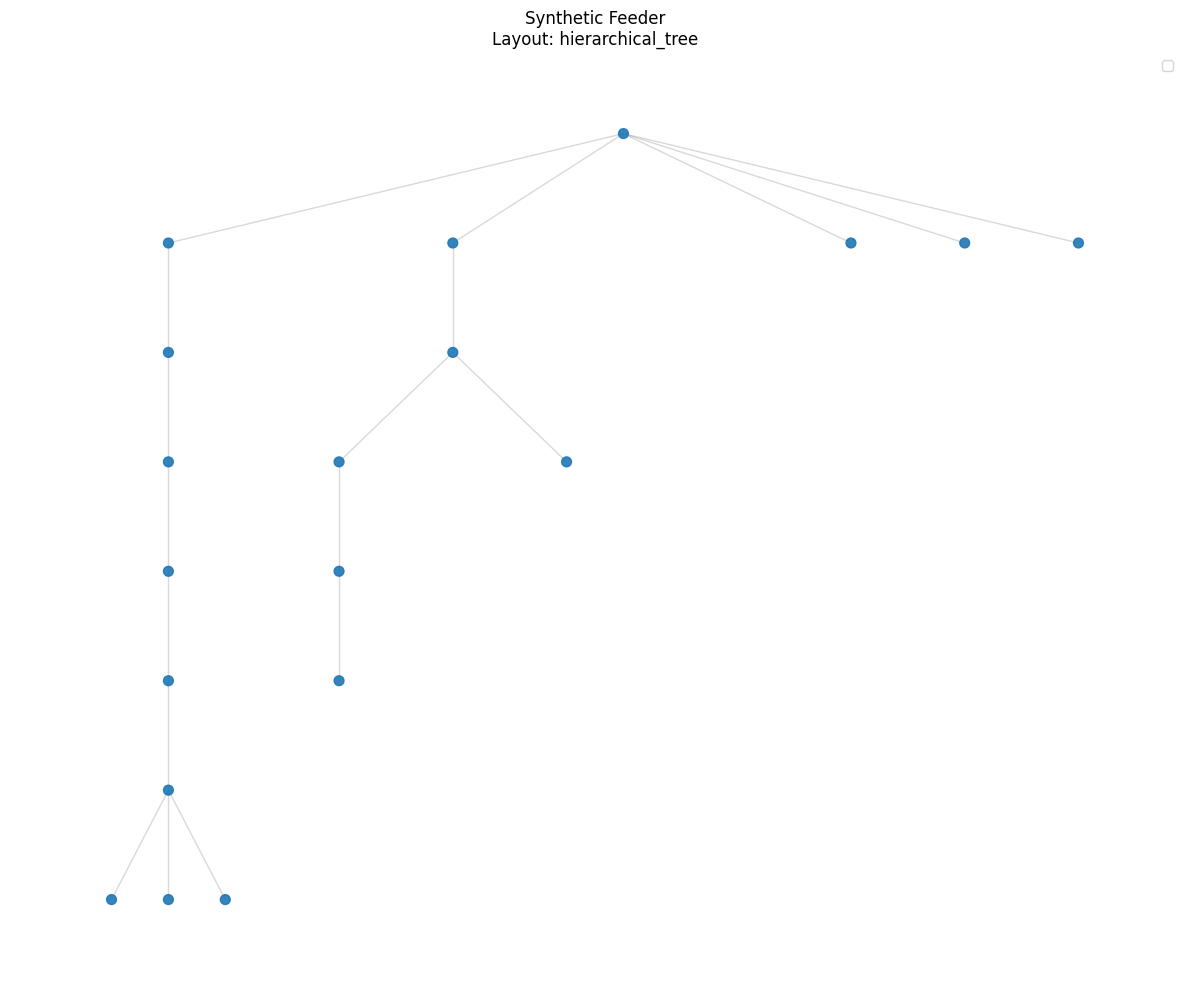

In [9]:
viz = GridVisualizer()
viz.plot_grid(ref, layout="hierarchical_tree", title="Reference Feeder (CIGRE LV via pypowsybl)")
plt.show()

viz.plot_grid(syn_feeder, layout="hierarchical_tree", title="Synthetic Feeder")
plt.show()

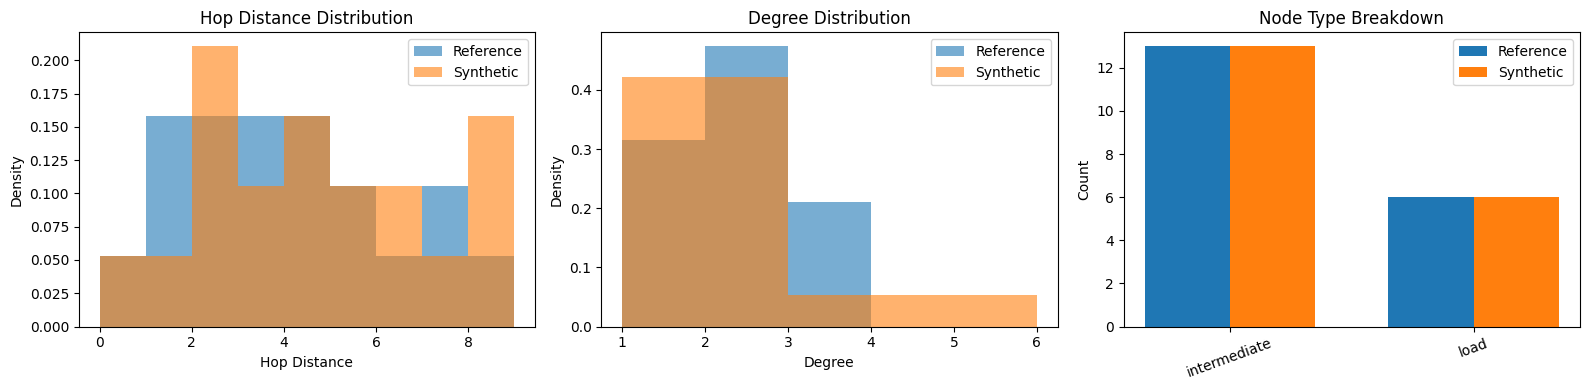

In [10]:
# Statistical distribution comparison
hops_ref = [ref.nodes[n]["h"] for n in ref.nodes]
hops_syn = [syn_feeder.nodes[n]["h"] for n in syn_feeder.nodes]
degs_ref = [ref.degree(n) for n in ref.nodes]
degs_syn = [syn_feeder.degree(n) for n in syn_feeder.nodes]
types_ref = Counter(ref.nodes[n].get("node_type", "unknown") for n in ref.nodes)
types_syn = Counter(syn_feeder.nodes[n].get("node_type", "unknown") for n in syn_feeder.nodes)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Hop distance histogram
max_hop = max(max(hops_ref), max(hops_syn))
axes[0].hist(hops_ref, bins=range(max_hop + 2), alpha=0.6, label="Reference", density=True)
axes[0].hist(hops_syn, bins=range(max_hop + 2), alpha=0.6, label="Synthetic", density=True)
axes[0].set_xlabel("Hop Distance")
axes[0].set_ylabel("Density")
axes[0].set_title("Hop Distance Distribution")
axes[0].legend()

# Degree histogram
max_deg = max(max(degs_ref), max(degs_syn))
axes[1].hist(degs_ref, bins=range(1, max_deg + 2), alpha=0.6, label="Reference", density=True)
axes[1].hist(degs_syn, bins=range(1, max_deg + 2), alpha=0.6, label="Synthetic", density=True)
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Density")
axes[1].set_title("Degree Distribution")
axes[1].legend()

# Node type breakdown
all_types = sorted(set(list(types_ref.keys()) + list(types_syn.keys())))
x = np.arange(len(all_types))
w = 0.35
axes[2].bar(x - w/2, [types_ref.get(t, 0) for t in all_types], w, label="Reference")
axes[2].bar(x + w/2, [types_syn.get(t, 0) for t in all_types], w, label="Synthetic")
axes[2].set_xticks(x)
axes[2].set_xticklabels(all_types, rotation=20)
axes[2].set_ylabel("Count")
axes[2].set_title("Node Type Breakdown")
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Ensemble Generation & Aggregate Comparison

Generate multiple synthetic feeders and compute aggregate KL-divergence statistics.

In [11]:
# Generate 10 synthetic feeders
ensemble = []
for i in range(10):
    g = SchweetzerFeederGenerator(params=fitted_params, seed=i)
    f = g.generate_feeder(
        n_nodes=n_target,
        total_load_mw=total_load if total_load > 0 else 1.0,
        total_gen_mw=total_gen if total_gen > 0 else 0.0,
    )
    ensemble.append(DistributionGrid.from_nx(f))

# Aggregate KL-divergence
all_kl = [compare_feeders(ref, s) for s in ensemble]
kl_keys = list(all_kl[0].keys())

print(f"{'Metric':<25} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 60)
for key in kl_keys:
    vals = [d[key] for d in all_kl]
    print(f"{key:<25} {np.mean(vals):>8.4f} {np.std(vals):>8.4f} "
          f"{np.min(vals):>8.4f} {np.max(vals):>8.4f}")

Metric                        Mean      Std      Min      Max
------------------------------------------------------------
hop_distance_kl             1.3559   1.4557   0.1191   4.1078
degree_kl                   0.7138   1.5712   0.0000   5.4168
cable_length_kl             1.3205   0.0000   1.3205   1.3205


## 8. Power-Flow Validation

Validate the synthetic distribution feeder using pandapower DC power flow
and pypowsybl AC load flow.

In [12]:
from powergrid_synth import GridExporter, nx_to_pandapower

# Export synthetic feeder to pandapower for DC power flow
net_syn = nx_to_pandapower(syn_feeder, base_kv_map={0: 0.4})

# Add ext_grid at root bus for power flow (required slack reference)
root_bus = 0  # root node
if len(net_syn.ext_grid) == 0:
    pp.create_ext_grid(net_syn, bus=root_bus, vm_pu=1.0)

print(f"pandapower network: {len(net_syn.bus)} buses, {len(net_syn.line)} lines, "
      f"{len(net_syn.ext_grid)} ext_grid")

try:
    pp.rundcpp(net_syn)
    print(f"DC power flow converged ✓")
    print(f"  Max voltage angle: {net_syn.res_bus.va_degree.max():.2f}°")
    print(f"  Min voltage angle: {net_syn.res_bus.va_degree.min():.2f}°")
except Exception as e:
    print(f"DC power flow: {e}")

pandapower network: 19 buses, 18 lines, 1 ext_grid
DC power flow converged ✓
  Max voltage angle: 0.00°
  Min voltage angle: 0.00°


In [13]:
# Convert to pypowsybl and run AC load flow
try:
    net_syn_ppl = pandapower_to_pypowsybl(net_syn)
    results = ppl.loadflow.run_ac(net_syn_ppl)
    print("pypowsybl AC load flow results:")
    for r in results:
        print(f"  Component {r.connected_component_num}: status={r.status.name}, "
              f"iterations={r.iteration_count}")
except Exception as e:
    print(f"pypowsybl AC load flow: {e}")

pypowsybl AC load flow results:
  Component 0: status=CONVERGED, iterations=1


## One-Line Synthesis

All the steps above — reference loading, parameter fitting, feeder generation,
validation, and export — can be performed with a single function call using
`synthesize_distribution()`.

Two modes are supported:

- **`mode="reference"`** — fit parameters from an existing network
  (pandapower, pypowsybl, or file), then generate synthetic feeders.
- **`mode="default"`** — use built-in Table III defaults (optionally
  overridden with a custom `DistributionSynthParams`).

In [14]:
from powergrid_synth.distribution import synthesize_distribution

# Reference-based: fit from CIGRE LV, generate 5 feeders
feeders_ref = synthesize_distribution(
    mode="reference",
    reference_case="cigre_lv",
    n_feeders=5,
    n_nodes=20,
    total_load_mw=0.5,
    seed=42,
    output_dir="output",
    output_name="cigre_lv_oneliner",
    export_formats=["json"],
)

[1] Loaded 1 reference feeder(s): avg 44 nodes.
[2] Generated 5 synthetic feeder(s): avg 20 nodes, 20 requested.
[3] KL divergence (feeder 0 vs ref 0): hop_distance_kl=0.630, degree_kl=1.217, cable_length_kl=26.334
-> pandapower JSON export: output/cigre_lv_oneliner_0.json
-> pandapower JSON export: output/cigre_lv_oneliner_1.json
-> pandapower JSON export: output/cigre_lv_oneliner_2.json
-> pandapower JSON export: output/cigre_lv_oneliner_3.json
-> pandapower JSON export: output/cigre_lv_oneliner_4.json
[4] Exported to output/
[Done]


In [15]:
# Default-parameter mode: no reference network needed
feeders_default = synthesize_distribution(
    mode="default",
    n_feeders=10,
    n_nodes=30,
    total_load_mw=0.8,
    seed=7,
)

print(f"\nGenerated {len(feeders_default)} feeders with default params:")
for i, f in enumerate(feeders_default):
    print(f"  Feeder {i}: {f.number_of_nodes()} nodes, {f.number_of_edges()} edges")

[1] Using default / user-supplied parameters.
[2] Generated 10 synthetic feeder(s): avg 30 nodes, 30 requested.
[3] Feeder 0 properties: 30 nodes, 29 edges, max_hop=13, load=0.810 MW
[Done]

Generated 10 feeders with default params:
  Feeder 0: 30 nodes, 29 edges
  Feeder 1: 30 nodes, 29 edges
  Feeder 2: 30 nodes, 29 edges
  Feeder 3: 30 nodes, 29 edges
  Feeder 4: 30 nodes, 29 edges
  Feeder 5: 30 nodes, 29 edges
  Feeder 6: 30 nodes, 29 edges
  Feeder 7: 30 nodes, 29 edges
  Feeder 8: 30 nodes, 29 edges
  Feeder 9: 30 nodes, 29 edges


## Summary

This notebook demonstrated the full distribution feeder synthesis workflow
using pypowsybl-supported formats:

1. **Loading** — reference distribution grid via pypowsybl (from CGMES file)
2. **Converting** — `pypowsybl_to_feeders()` to Schweitzer-format feeder graphs
3. **Fitting** — statistical parameters from reference feeders
4. **Generating** — synthetic feeders using the Schweitzer algorithm
5. **Validating** — KL-divergence comparison and emergent property analysis
6. **Visualization** — topology and distribution comparisons
7. **Power-flow** — DC (pandapower) and AC (pypowsybl) validation
8. **One-liner** — `synthesize_distribution()` for the complete pipeline in a single call

Any pypowsybl-supported format can be used as the input source:
CGMES, XIIDM, IEEE-CDF, MATPOWER, PSS/E, UCTE, BIIDM, JIIDM, POWER-FACTORY.